# <br><center> Exploring the paired T-test using cross validation

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (14,8),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.2
})

import scipy.stats as stats
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.datasets import load_diabetes

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from dotenv import load_dotenv
load_dotenv()

import gc; gc.enable()
from IPython.display import clear_output, display
from tqdm.notebook import tqdm

print("setup done!")

setup done!


In [2]:
# load data
ds = load_diabetes()
desc = ds["DESCR"]

X = ds["data"]
y = ds["target"]

del ds; gc.collect()
print(desc)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
# cross validation
model1 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=30,
    random_state=67
)

model2 = CatBoostRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=30,
    random_state=67,
)

n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=67)

xs = np.zeros(n_splits)
ys = np.zeros(n_splits)
for fold, (train_idx, test_idx) in enumerate(tqdm(kf.split(X), desc="Model Evaluation", leave=False)):
    x_train, y_train = X[train_idx], y[train_idx]
    x_test, y_test = X[test_idx], y[test_idx]

    model1.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=100)
    model2.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=100)

    y_pred_1 = model1.predict(x_test)
    y_pred_2 = model2.predict(x_test)

    xs[fold] = root_mean_squared_error(y_test, y_pred_1)
    ys[fold] = root_mean_squared_error(y_test, y_pred_2)


Model Evaluation: 0it [00:00, ?it/s]

[0]	validation_0-rmse:77.41734	validation_1-rmse:69.19956
[100]	validation_0-rmse:55.54268	validation_1-rmse:52.69567
[199]	validation_0-rmse:48.24864	validation_1-rmse:51.57602
0:	learn: 77.5172539	test: 77.5172539	test1: 69.2663523	best: 69.2663523 (0)	total: 60.1ms	remaining: 12s
100:	learn: 60.4636197	test: 60.4636197	test1: 54.5233575	best: 54.5233575 (100)	total: 75.9ms	remaining: 74.4ms
199:	learn: 54.5762663	test: 54.5762663	test1: 52.4849770	best: 52.4632421 (188)	total: 99.5ms	remaining: 0us

bestTest = 52.46324207
bestIteration = 188

Shrink model to first 189 iterations.
[0]	validation_0-rmse:77.18548	validation_1-rmse:71.53946
[100]	validation_0-rmse:55.86062	validation_1-rmse:54.86537
[199]	validation_0-rmse:48.72413	validation_1-rmse:50.25234
0:	learn: 77.2354922	test: 77.2354922	test1: 71.5678505	best: 71.5678505 (0)	total: 184us	remaining: 36.7ms
100:	learn: 60.5278007	test: 60.5278007	test1: 55.3932419	best: 55.3932419 (100)	total: 17.5ms	remaining: 17.1ms
199:	learn:

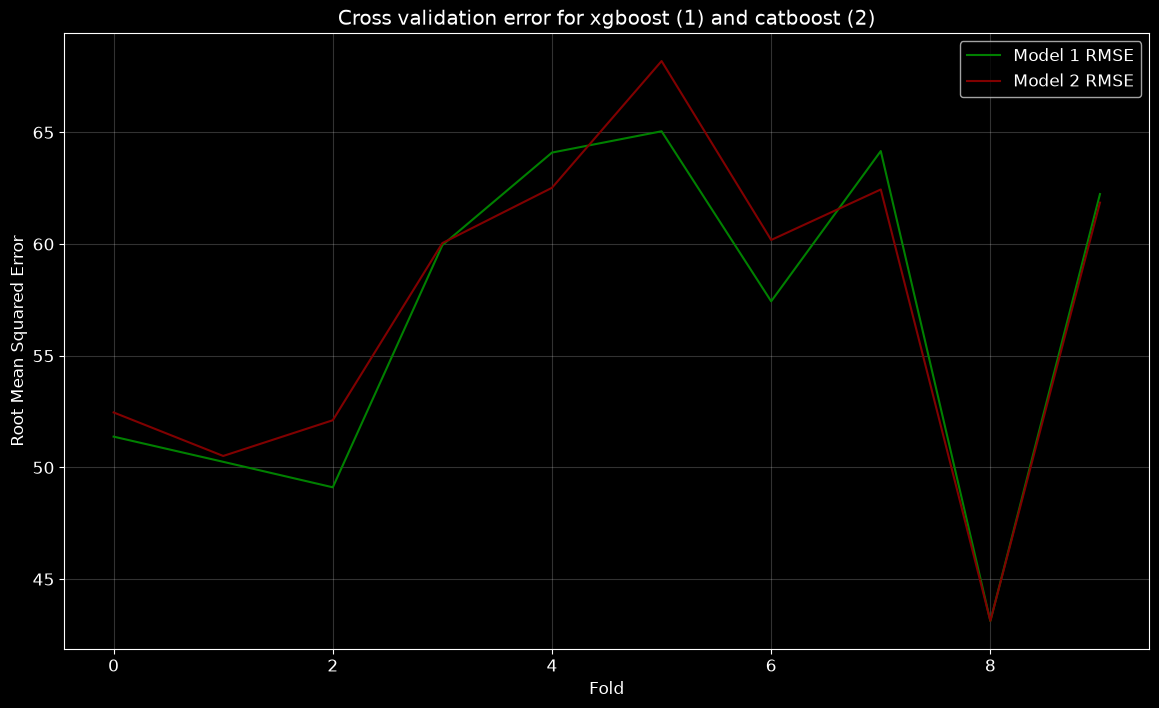

In [4]:
plt.plot(xs, color="green", label="Model 1 RMSE")
plt.plot(ys, color="maroon", label="Model 2 RMSE")
plt.title("Cross validation error for xgboost (1) and catboost (2)")
plt.xlabel("Fold")
plt.ylabel("Root Mean Squared Error")
plt.legend()
plt.show()

In [5]:
# paired t-test
results = stats.ttest_1samp(xs - ys, popmean=0)
print(f"T-test results: t={results.statistic:.4f}, p={results.pvalue:.8f}, df={int(results.df)}")

T-test results: t=-1.1761, p=0.26972369, df=9


### Conclusion 1
Looking at the results of the t-test, we see that as our $p$-value was greater than 0.05, the experiment is inconclusive as of now, <br> and we need more data to effectively support that one model is better than the other.

In [6]:
# cross validation
model1 = XGBRegressor(
    early_stopping_rounds=30,
    random_state=67
)

model2 = LGBMRegressor(
    early_stopping_rounds=30,
    random_state=67,
    verbose=-100
)

n_splits = 25
kf = KFold(n_splits=n_splits, shuffle=True, random_state=67)

xs = np.zeros(n_splits)
ys = np.zeros(n_splits)
for fold, (train_idx, test_idx) in enumerate(tqdm(kf.split(X), desc="Model Evaluation", leave=False)):
    x_train, y_train = X[train_idx], y[train_idx]
    x_test, y_test = X[test_idx], y[test_idx]

    model1.fit(x_train, y_train, eval_set=[(x_train, y_train), (x_test, y_test)], verbose=100)
    model2.fit(x_train, y_train, eval_X=(x_train, x_test), eval_y=(y_train, y_test))

    y_pred_1 = model1.predict(x_test)
    y_pred_2 = model2.predict(x_test)

    xs[fold] = root_mean_squared_error(y_test, y_pred_1)
    ys[fold] = root_mean_squared_error(y_test, y_pred_2)

Model Evaluation: 0it [00:00, ?it/s]

[0]	validation_0-rmse:62.33795	validation_1-rmse:61.70790
[38]	validation_0-rmse:4.95443	validation_1-rmse:57.71659
[0]	validation_0-rmse:62.41326	validation_1-rmse:55.18423
[31]	validation_0-rmse:8.34555	validation_1-rmse:65.58076
[0]	validation_0-rmse:62.58202	validation_1-rmse:76.59955
[69]	validation_0-rmse:1.24778	validation_1-rmse:53.71764
[0]	validation_0-rmse:62.55269	validation_1-rmse:57.10026
[34]	validation_0-rmse:6.82724	validation_1-rmse:57.93692
[0]	validation_0-rmse:62.67978	validation_1-rmse:62.03816
[49]	validation_0-rmse:3.21321	validation_1-rmse:54.59115
[0]	validation_0-rmse:62.50079	validation_1-rmse:61.85769
[88]	validation_0-rmse:0.57171	validation_1-rmse:48.11377
[0]	validation_0-rmse:61.93694	validation_1-rmse:74.23008
[36]	validation_0-rmse:5.93246	validation_1-rmse:65.90144
[0]	validation_0-rmse:61.30579	validation_1-rmse:82.90889
[50]	validation_0-rmse:3.47416	validation_1-rmse:60.57641
[0]	validation_0-rmse:62.29084	validation_1-rmse:80.68901
[54]	validatio

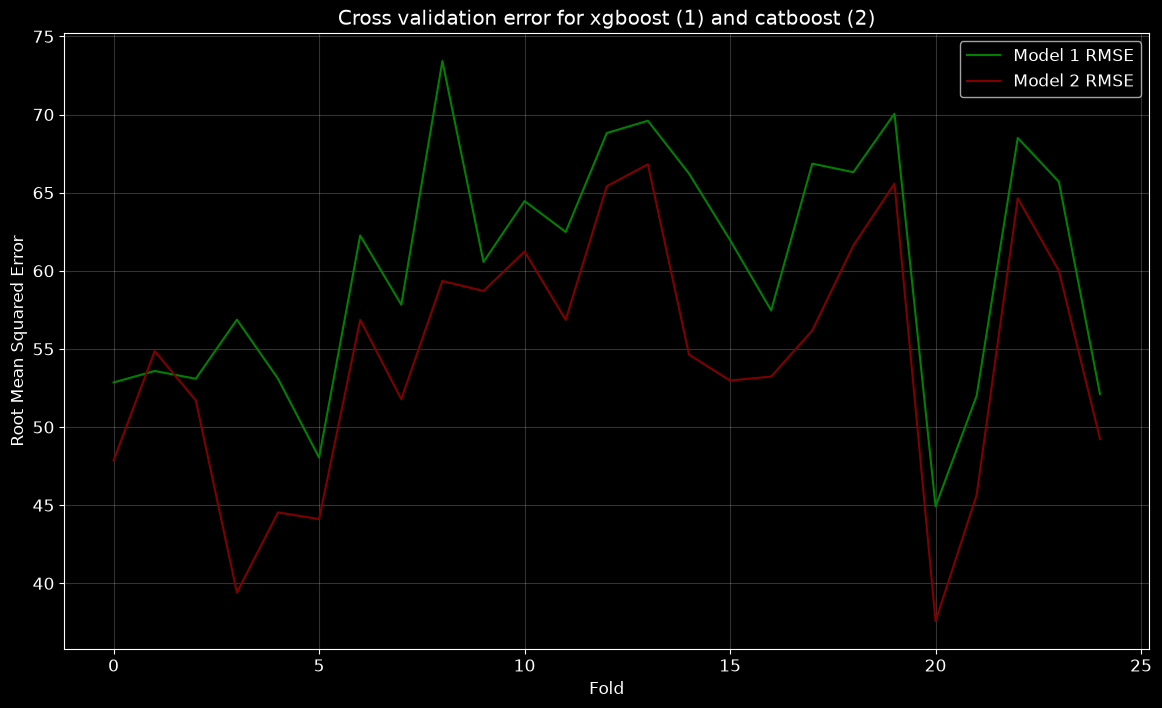

In [7]:
plt.plot(xs, color="green", label="Model 1 RMSE")
plt.plot(ys, color="maroon", label="Model 2 RMSE")
plt.title("Cross validation error for xgboost (1) and catboost (2)")
plt.xlabel("Fold")
plt.ylabel("Root Mean Squared Error")
plt.legend()
plt.show()

In [8]:
# paired t-test
results = stats.ttest_1samp(xs - ys, popmean=0)
print(f"T-test results: t={results.statistic:.4f}, p={results.pvalue:.8f}, df={int(results.df)}")

T-test results: t=7.1692, p=0.00000021, df=24


### Conclusion 2
Looking at the data, we see that the LightGBM regressor likely outperforms the XGBRegressor as suggested by our t-test.

The $p$-value suggests extremely high levels of statistical significance, which is strong evidence that the gradient booster performed best on this dataset.